# Comparison — Sinusoidal vs Learned

Visualize and compare the two absolute positional encoding methods.

**Pre-requisites:** complete `01_sinusoidal_exercise.ipynb` and `02_learned_exercise.ipynb` first.

## Setup

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)


# --- Inline copies of the implementations from the previous exercise notebooks ---
# (Keeping this notebook self-contained — re-run after editing the solutions if needed.)

def get_frequencies(d_model: int) -> torch.Tensor:
    i = torch.arange(d_model // 2)
    return 1 / torch.pow(10000, 2 * i / d_model)


def sinusoidal_pe(max_len: int, d_model: int) -> torch.Tensor:
    pe = torch.zeros(max_len, d_model)
    omega = get_frequencies(d_model)
    positions = torch.arange(max_len)
    angles = positions[:, None] * omega[None, :]   # (max_len, d_model // 2)
    pe[:, 0::2] = torch.sin(angles)
    pe[:, 1::2] = torch.cos(angles)
    return pe


class LearnedPositionalEmbedding(nn.Module):
    def __init__(self, max_len: int, d_model: int):
        super().__init__()
        self.position_embeddings = nn.Embedding(max_len, d_model)

    def forward(self, token_embeddings):
        seq_len = token_embeddings.shape[1]
        positions = torch.arange(seq_len, device=token_embeddings.device)
        return token_embeddings + self.position_embeddings(positions)

## 1. Heatmap of sinusoidal PE

Plot `sinusoidal_pe(max_len=128, d_model=128)` as a heatmap. You should see horizontal stripes — different frequencies on different dimensions.

sinusoidal PE shape: (128, 128)


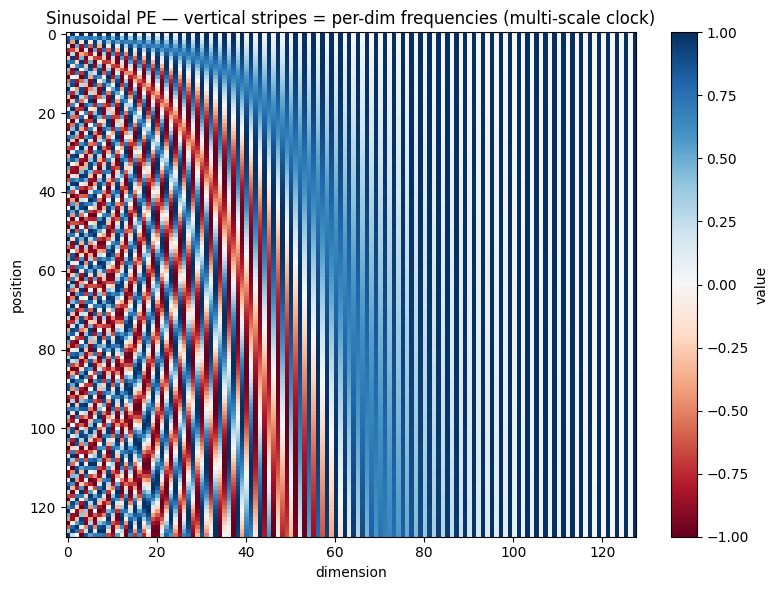

In [3]:
pe_sin = sinusoidal_pe(max_len=128, d_model=128)
print(f"sinusoidal PE shape: {tuple(pe_sin.shape)}")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pe_sin, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax.set_xlabel("dimension")
ax.set_ylabel("position")
ax.set_title("Sinusoidal PE — vertical stripes = per-dim frequencies (multi-scale clock)")
plt.colorbar(im, ax=ax, label="value")
plt.tight_layout()
plt.show()

## 2. Heatmap of learned PE (random init)

Untrained learned PE is just random noise. Plot it for contrast.

learned PE shape: (128, 128)


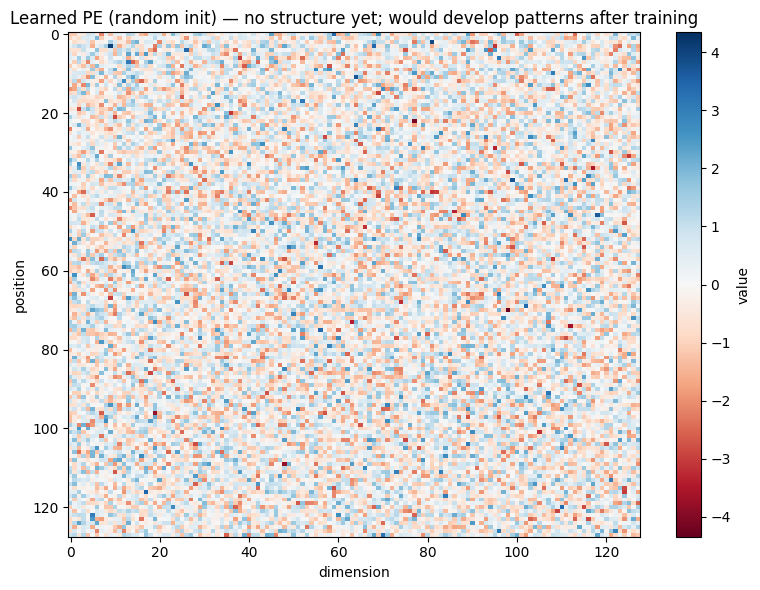

In [4]:
torch.manual_seed(0)
learned_module = LearnedPositionalEmbedding(max_len=128, d_model=128)
pe_learned = learned_module.position_embeddings.weight.detach()
print(f"learned PE shape: {tuple(pe_learned.shape)}")

# Symmetric color range so the noise pattern is readable
v = pe_learned.abs().max().item()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pe_learned, aspect='auto', cmap='RdBu', vmin=-v, vmax=v)
ax.set_xlabel("dimension")
ax.set_ylabel("position")
ax.set_title("Learned PE (random init) — no structure yet; would develop patterns after training")
plt.colorbar(im, ax=ax, label="value")
plt.tight_layout()
plt.show()

## 3. Distance decay

Plot the cosine similarity between $PE(0)$ and $PE(k)$ as $k$ increases from 0 to 127. Sinusoidal should show a smooth decay; random learned PE should look like noise.

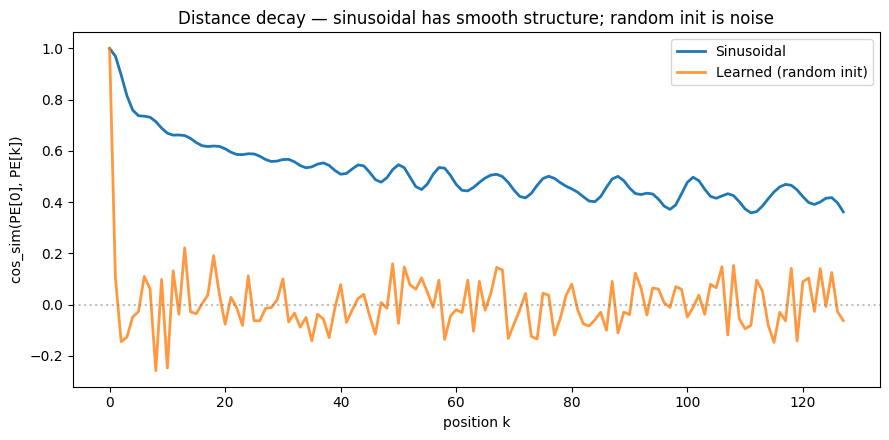

In [5]:
def cos_sim_to_first(pe: torch.Tensor) -> torch.Tensor:
    """For each row k, return cosine similarity between row 0 and row k."""
    a = pe[0:1]                             # (1, d_model)
    return (pe @ a.T).squeeze(-1) / (
        pe.norm(dim=-1) * a.norm(dim=-1) + 1e-8
    )


sims_sin = cos_sim_to_first(pe_sin)
sims_learned = cos_sim_to_first(pe_learned)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sims_sin, label="Sinusoidal", linewidth=2)
ax.plot(sims_learned, label="Learned (random init)", linewidth=2, alpha=0.8)
ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel("position k")
ax.set_ylabel("cos_sim(PE[0], PE[k])")
ax.set_title("Distance decay — sinusoidal has smooth structure; random init is noise")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Position 0 reference vector

Plot the value at each dimension for $PE(0)$, $PE(50)$, $PE(127)$ as a line plot. For sinusoidal you should see clearly different patterns. For learned, just three random vectors.

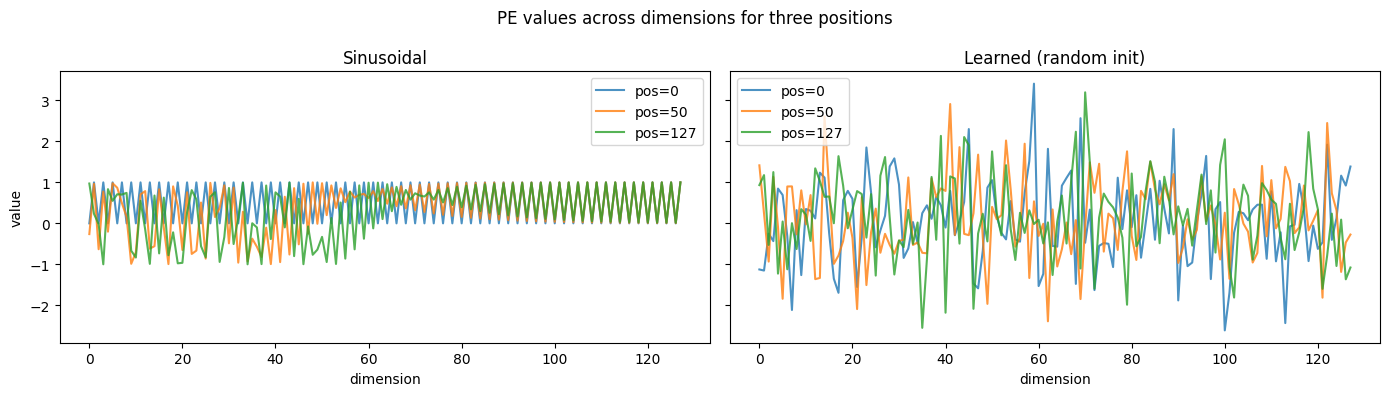

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

positions_to_plot = [0, 50, 127]

for ax, pe, title in [(axes[0], pe_sin,    "Sinusoidal"),
                      (axes[1], pe_learned, "Learned (random init)")]:
    for pos in positions_to_plot:
        ax.plot(pe[pos].numpy(), label=f"pos={pos}", alpha=0.8)
    ax.set_xlabel("dimension")
    ax.set_title(title)
    ax.legend()

axes[0].set_ylabel("value")
plt.suptitle("PE values across dimensions for three positions")
plt.tight_layout()
plt.show()

## Takeaways

1. **Sinusoidal has visible structure; random learned PE is noise.** The heatmaps make this immediate — sinusoidal shows the multi-frequency clock (vertical stripes corresponding to different $\omega_i$), while untrained learned PE is pure init noise. After training, the learned version develops structure, but it's task-specific patterns rather than an elegant frequency decomposition.

2. **Distance decay tells the same story.** Sinusoidal's $\text{cos\_sim}(PE[0], PE[k])$ decays smoothly with $k$ — nearby positions have similar encodings, distant positions are decorrelated. Random learned PE shows no such trend; the similarity hovers around zero for all $k$.

3. **Both encode *absolute* position.** Every position gets a unique fingerprint, but neither makes *relative* position cheap. To learn "subject precedes verb by 1," the model has to discover separate patterns for (pos 1 → pos 2), (pos 3 → pos 4), and so on. With relative methods (Part 2), it learns the single pattern "distance = 1" once and reuses it everywhere.

4. **Length generalization is fragile.** Even though sinusoidal can mathematically extend beyond training length, the model's attention patterns were never trained for those position values — so they don't transfer. Learned PE doesn't even have entries beyond `max_len`. Both motivate the move to relative methods.

→ Continue to `blog/03-positional-encoding-relative/` to see how T5's bias, ALiBi, and RoPE solve the relative-position problem.